# Applying TDA to US house of representatives voting data
Goal: Reproduce the results from the paper "Extracting insights from the shape of complex data using topology" (https://www.nature.com/articles/srep01236)

Method: We intend to use the python package kmapper to apply the mapper algorithm to the minimal dataset, created in `TDA_practical/exploratory/data_csv_structure.ipynb`


# First try on mapper implementation: 

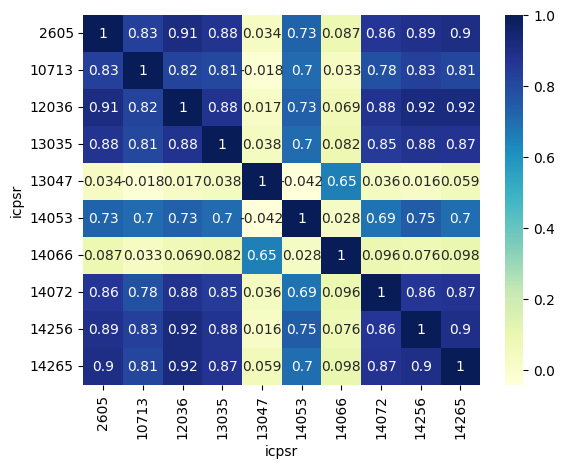

In [11]:
import pandas as pd
import numpy as np
import kmapper as km
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering
import networkx as nx
from kmapper.adapter import to_networkx


df_data = pd.read_csv("../data/processed_data.csv")

vote_matrix_09 = df_data[df_data['date'] < '2010-01-01'].pivot(index='icpsr', columns='rollnumber', values='paper_cast_code').fillna(0)
vote_matrix_10 = df_data[df_data['date'] >= '2010-01-01'].pivot(index='icpsr', columns='rollnumber', values='paper_cast_code').fillna(0)

corr_09 = vote_matrix_09.T.corr()
corr_10 = vote_matrix_10.T.corr()

sns.heatmap(corr_09.iloc[:10, :10], cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()


Next we compute the distance matrix from the correlation and compute the SVD as in the paper, 

In [3]:
distance_09 = (1 - corr_09).fillna(0)
distance_10 = (1 - corr_10).fillna(0)

U_09, singular_values_09, Vt_09 = np.linalg.svd(distance_09.to_numpy())
U_10, singular_values_10, Vt_10 = np.linalg.svd(distance_10.to_numpy())

lens_09 = (U_09 @ np.diag(singular_values_09))[:,:2]
lens_10 = (U_10 @ np.diag(singular_values_10))[:,:2]


In [70]:

from customClustering import DynamicSingleLinkage

mapper = km.KeplerMapper()

cover = km.Cover(
    n_cubes=34,
    perc_overlap=0.55,
)
#clusterer = AgglomerativeClustering(
#    distance_threshold=0.5,
#    n_clusters=None,
#    linkage="single")
#clusterer = DynamicSingleLinkage(
#    N_bins = 30,
#    lowerMergerThreshold = 0.75,
#    debug = False
#)

clusterer = DBSCAN(
    metric="precomputed",
    eps=2.5,
    min_samples=1,
)

graph_09 = mapper.map(
    lens_09,
    X=distance_09.to_numpy(),
    precomputed=True,
    cover=cover,
    clusterer=clusterer,
    remove_duplicate_nodes=True,
)
graph_10 = mapper.map(
    lens_10,
    X=distance_10.to_numpy(),
    precomputed=True,
    cover=cover,
    clusterer=clusterer,
    remove_duplicate_nodes=True,
)

G_09 = to_networkx(graph_09)
G_10 = to_networkx(graph_10)

n_components_09 = nx.number_connected_components(G_09)
print(n_components_09)

n_components_10 = nx.number_connected_components(G_10)
print(n_components_10)

15
29


Compute number of connected componenents of the graphs to compare with the paper. (2009: 10, 2010: 37) Also compute visualizations colored by party

In [15]:
G_09 = to_networkx(graph_09)
G_10 = to_networkx(graph_10)

n_components_09 = nx.number_connected_components(G_09)
print(n_components_09)

n_components_10 = nx.number_connected_components(G_10)
print(n_components_10)

59
41


In [71]:
member_info = (
    df_data[["icpsr", "party_name", "bioname"]]
    .drop_duplicates("icpsr")
    .set_index("icpsr")
)

party_color = (
    member_info["party_name"]
    .map({
        "Democrat": 0.0,
        "Republican": 1.0,
    })
    .fillna(0.5)
    .to_numpy()
)

mapper.visualize(
    graph_09,
    path_html="house_mapper_2009.html",
    title="US House voting behavior, 2009",
    color_values=party_color,
    color_function_name="Party",
    node_color_function="mean",
    colorscale=[
        [0.0, "#0000ff"],
        [0.5, "#b0b0b0"],
        [1.0, "#ff0000"],
    ],
    custom_tooltips=member_info["bioname"].to_numpy(),
)

mapper.visualize(
    graph_10,
    path_html="house_mapper_2010.html",
    title="US House voting behavior, 2010",
    color_values=party_color,
    color_function_name="Party",
    node_color_function="mean",
    colorscale=[
        [0.0, "#0000ff"],
        [0.5, "#b0b0b0"],
        [1.0, "#ff0000"],
    ],
    custom_tooltips=member_info["bioname"].to_numpy(),
)

'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>US House voting behavior, 2010 | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13

### Single Linkage with parameters search like in paper (Histogram) (for testing, implementation in customClustering.py)

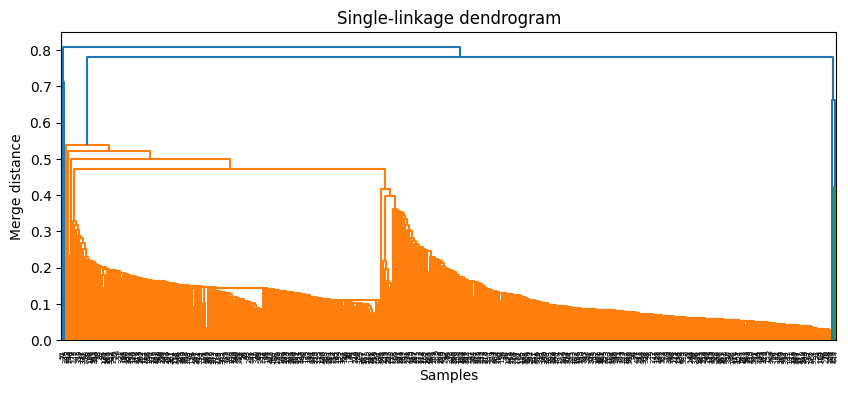

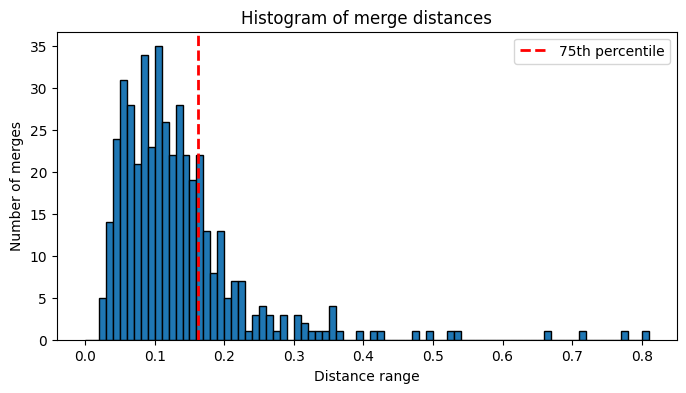

In [10]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0,
    linkage="single",
    metric="precomputed",
    compute_distances=True,
).fit(distance_09)

# Build SciPy linkage matrix for the dendrogram
n = len(distance_09)
counts = np.zeros(len(model.children_))

merge_percentile = 75
merge_distance = np.percentile(model.distances_, merge_percentile)

for i, (left, right) in enumerate(model.children_):
    counts[i] = (
        (1 if left < n else counts[left - n])
        + (1 if right < n else counts[right - n])
    )

linkage_matrix = np.column_stack([
    model.children_,
    model.distances_,
    counts,
])

# Dendrogram
plt.figure(figsize=(10, 4))
dendrogram(linkage_matrix)
plt.xlabel("Samples")
plt.ylabel("Merge distance")
plt.title("Single-linkage dendrogram")
plt.show()

# Histogram of merge distances
bin_width = 0.01
bins = np.arange(0, model.distances_.max() + bin_width, bin_width)

plt.figure(figsize=(8, 4))
plt.hist(model.distances_, bins=bins, edgecolor="black")
plt.axvline(merge_distance, color="red", linestyle="--", linewidth=2, label=f"{merge_percentile}th percentile")
plt.xlabel("Distance range")
plt.ylabel("Number of merges")
plt.title("Histogram of merge distances")
plt.legend()
plt.show()

Its optimizing time

In [82]:
def num_connected_components(mapper_graph):
    G = to_networkx(mapper_graph)
    return nx.number_connected_components(G)

def mapper_component_count(X, lens, n_cubes, perc_overlap, eps = 0.0, min_samples= 0.0, threshold=0.0):
    mapper = km.KeplerMapper()

    graph = mapper.map(
        lens,
        X,
        cover=km.Cover(
            n_cubes=n_cubes,
            perc_overlap=perc_overlap
        ),
        clusterer = DynamicSingleLinkage(
        N_bins = 30,
        lowerMergerThreshold = threshold,
        debug = False

        )
    )

    return num_connected_components(graph)

def objective_value(params):
    n_cubes = params["n_cubes"]
    perc_overlap = params["perc_overlap"]
    eps = params["eps"]
    min_samples = params["min_samples"]
    threshold = params["threshold"]

    c_09 = mapper_component_count(
        lens=lens_09,
        X=distance_09.to_numpy(),
        n_cubes=n_cubes,
        perc_overlap=perc_overlap,
        eps=eps,
        min_samples=min_samples,
        threshold=threshold
    )

    c_10 = mapper_component_count(
        lens=lens_10,
        X=distance_10.to_numpy(),
        n_cubes=n_cubes,
        perc_overlap=perc_overlap,
        eps=eps,
        min_samples=min_samples,
        threshold=threshold
    )

    loss = abs(c_09 - target_09) + abs(c_10 - target_10)
    #loss = (c_09 - target_09)**2 + (c_10 - target_10)**2

    return loss, c_09, c_10

In [83]:
import random
import pandas as pd

results = []

target_09 = 10
target_10 = 37

for trial in range(100):
    print(trial)
    params = {
        "n_cubes": random.randint(5, 100),
        "perc_overlap": random.uniform(0.1, 0.8),
        "eps": 0,#random.uniform(0.1, 5.0),
        "min_samples":0, #random.randint(1, 10),
        "threshold": random.uniform(0.1, 0.9)
    }

    loss, c_09, c_10 = objective_value(params)

    results.append({
        **params,
        "components_09": c_09,
        "components_10": c_10,
        "loss": loss
    })

df_results = pd.DataFrame(results)
df_results.sort_values("loss").head(10)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


,n_cubes,perc_overlap,eps,min_samples,threshold,components_09,components_10,loss
27,62,0.753311,0,0,0.857691,32,35,24
68,28,0.679010,0,0,0.686279,25,26,26
18,38,0.786992,0,0,0.894324,15,15,27
77,24,0.722040,0,0,0.868318,11,8,30
8,10,0.555337,0,0,0.825260,17,13,31
86,24,0.467183,0,0,0.830791,38,40,31
69,15,0.621822,0,0,0.866604,12,8,31
55,79,0.757633,0,0,0.719923,38,34,31
76,26,0.504664,0,0,0.885600,39,40,32
74,51,0.730944,0,0,0.708804,38,41,32
